In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [101]:
mean_plus_spec_pred = pd.read_csv('../data_obtain/mean_plus_predict_aa.csv', index_col=0)
mean_minus_spec_pred = pd.read_csv('../data_obtain/mean_minus_predict_aa.csv', index_col=0)
mean_ds_spec_pred = pd.read_csv('../data_obtain/mean_ds_predict_aa.csv', index_col=0)

In [102]:
mean_plus_spec_pred['strand'] = 'positive '
mean_minus_spec_pred['strand'] = 'negative'
mean_ds_spec_pred['strand'] = 'double'

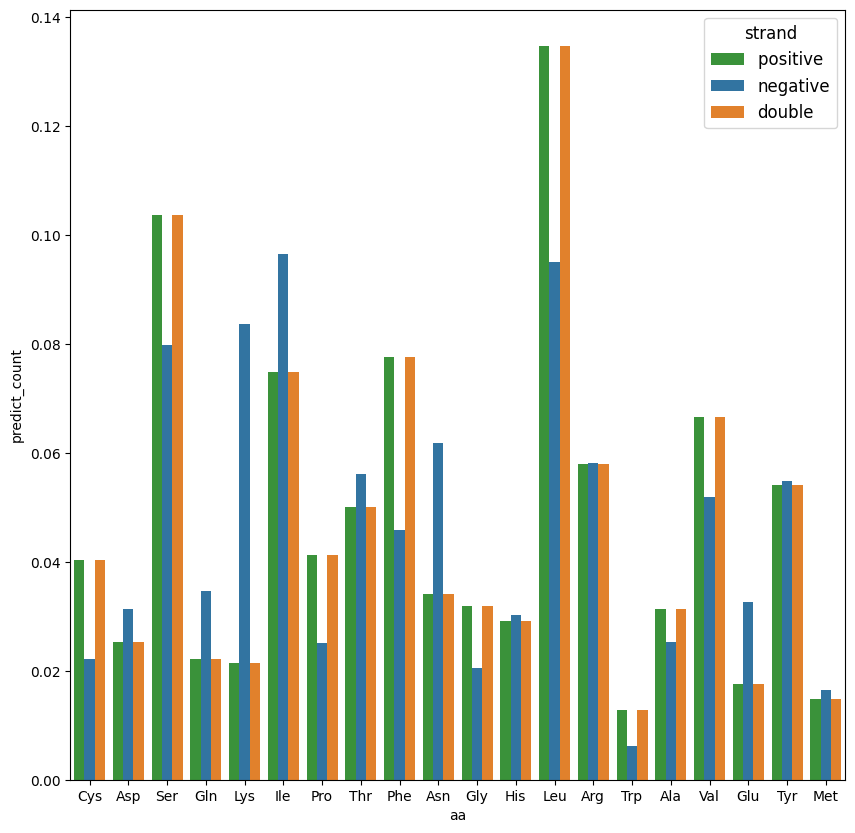

In [103]:
concat = pd.concat([mean_plus_spec_pred, mean_minus_spec_pred, mean_ds_spec_pred])
concat = concat.reset_index(drop=True)
concat = concat.melt(id_vars = 'strand')
concat = concat.rename(columns = {'variable':'aa', 'value':'predict_count'})
d = {'C': 'Cys', 'D': 'Asp', 'S': 'Ser', 'Q': 'Gln', 'K': 'Lys',
     'I': 'Ile', 'P': 'Pro', 'T': 'Thr', 'F': 'Phe', 'N': 'Asn', 
     'G': 'Gly', 'H': 'His', 'L': 'Leu', 'R': 'Arg', 'W': 'Trp', 
     'A': 'Ala', 'V':'Val', 'E': 'Glu', 'Y': 'Tyr', 'M': 'Met'}
palette = {
    'double': 'tab:orange',
    'positive ': 'tab:green',
    'negative' : 'tab:blue'
}
fig = plt.figure(figsize=(10, 10))
order_list = list(d.values())
ax = sns.barplot(x="aa", y='predict_count', hue="strand", data=concat, ax=fig.gca(), palette=palette, order = order_list)
fig.savefig('../figures/predicted_aa_concat.pdf', dpi=300, bbox_inches = 'tight')

In [104]:
#mean_plus_spec_real = pd.read_csv('../data_obtain/mean_aa_real_plus.csv', index_col=0)
#mean_minus_spec_real = pd.read_csv('../data_obtain/mean_aa_real_minus.csv', index_col=0)
#mean_ds_spec_real = pd.read_csv('../data_obtain/mean_aa_real_ds.csv', index_col=0)

In [105]:
viruses_specs = pd.read_csv('../data/ms12syn_all_virus.csv')
viruses_type = pd.read_csv('../data/taxid_virus_type.csv')
viruses_aa_freq = pd.read_csv('../data/aminoacid_freq_all_virus.csv')
viruses_aa_freq_eq = pd.read_csv('../data/aminoacid_eq_freq_all_virus.csv')
d = {'C': 'Cys', 'D': 'Asp', 'S': 'Ser', 'Q': 'Gln', 'K': 'Lys',
     'I': 'Ile', 'P': 'Pro', 'T': 'Thr', 'F': 'Phe', 'N': 'Asn', 
     'G': 'Gly', 'H': 'His', 'L': 'Leu', 'R': 'Arg', 'W': 'Trp', 
     'A': 'Ala', 'V':'Val', 'E': 'Glu', 'Y': 'Tyr', 'M': 'Met'}

viruses_aa_freq.columns = [d[col] if col in d else col for col in viruses_aa_freq.columns]
viruses_type[viruses_type['Type'] == '-']['taxid'].unique()
viruses_aa_freq_eq['taxid'] = viruses_aa_freq_eq['taxid'].apply(str)
viruses_type['taxid'] = viruses_type['taxid'].apply(str)
viruses_specs['taxid'] = viruses_specs['taxid'].apply(str)
viruses_aa_freq['taxid'] = viruses_aa_freq['taxid'].apply(str)
#viruses_specs.loc[viruses_specs['taxid'] == '118655(1933309)','taxid'] = '118655'
#viruses_type.loc[viruses_type['taxid'] == '1933309','taxid'] = '118655'

#viruses_specs.loc[viruses_specs['taxid'] == '54290_1985356','taxid'] = '54290'
#viruses_type.loc[viruses_type['taxid'] == '1985356','taxid'] = '54290'
viruses_type = viruses_type.rename(columns={"taxid": "virus_name", "Type" : "RNAsense"})
viruses_type = viruses_type[['virus_name', "RNAsense"]]
viruses_specs = viruses_specs.rename(columns={"taxid": "virus_name"})
viruses_specs = viruses_specs.merge(viruses_type, how='left', on='virus_name')
#viruses_specs.loc[viruses_specs['virus_name'].isin(['11320_1', '11320_2', '3052493', '1133363', '3052763']), 'RNAsense'] = '-'

viruses_aa_freq = viruses_aa_freq.drop('refseq_id', axis=1)
viruses_aa_freq = viruses_aa_freq.set_index(list(viruses_aa_freq)[0]).stack()
viruses_aa_freq = viruses_aa_freq.reset_index()
viruses_aa_freq = viruses_aa_freq.rename(columns={"taxid": "virus_name", 'level_1':'aa', 0:'count'})
viruses_aa_freq = viruses_aa_freq.merge(viruses_type, how='left', on='virus_name')
#viruses_aa_freq.loc[viruses_aa_freq['virus_name'].isin(['11320', '3052493', '1133363', '3052763', '3052310']), 'RNAsense'] = '-'

In [106]:
taxid_virus_type = pd.read_csv('../data/taxid_virus_type.csv')

In [107]:
viruses_aa_freq_eq.columns = [d[col] if col in d else col for col in viruses_aa_freq_eq.columns]
#viruses_aa_freq_eq = viruses_aa_freq_eq.drop('refseq_id', axis=1)
#viruses_aa_freq_eq = viruses_aa_freq_eq.set_index(list(viruses_aa_freq_eq)[0]).stack()
#viruses_aa_freq_eq = viruses_aa_freq_eq.reset_index()
viruses_aa_freq_eq = viruses_aa_freq_eq.rename(columns={"taxid": "virus_name"})
viruses_aa_freq_eq = viruses_aa_freq_eq.merge(viruses_type, how='left', on='virus_name')

In [108]:
mean_plus_spec_pred = pd.DataFrame(viruses_aa_freq_eq[viruses_aa_freq_eq['RNAsense'] == '+'].drop(['virus_name', 'RNAsense'], axis=1).mean(axis=0)).reset_index().rename(columns={"index": "aa", 0:'predict_count'})
mean_plus_spec_pred['strand'] = 'positive '
mean_minus_spec_pred = pd.DataFrame(viruses_aa_freq_eq[viruses_aa_freq_eq['RNAsense'] == '-'].drop(['virus_name', 'RNAsense'], axis=1).mean(axis=0)).reset_index().rename(columns={"index": "aa", 0:'predict_count'})
mean_minus_spec_pred['strand'] = 'negative'
mean_ds_spec_pred = pd.DataFrame(viruses_aa_freq_eq[viruses_aa_freq_eq['RNAsense'] == 'ds'].drop(['virus_name', 'RNAsense'], axis=1).mean(axis=0)).reset_index().rename(columns={"index": "aa", 0:'predict_count'})
mean_ds_spec_pred['strand'] = 'double'

In [109]:
viruses_aa_freq['Strand'] = ''
viruses_aa_freq = viruses_aa_freq[viruses_aa_freq.aa != 'X']
viruses_aa_freq.loc[viruses_aa_freq['RNAsense'] == 'ds','Strand'] = 'double'
viruses_aa_freq.loc[viruses_aa_freq['RNAsense'] == '+','Strand'] = 'positive '
viruses_aa_freq.loc[viruses_aa_freq['RNAsense'] == '-','Strand'] = 'negative'

In [110]:
mean_plus_spec_real = viruses_aa_freq[viruses_aa_freq['Strand'] == 'positive ']
mean_minus_spec_real = viruses_aa_freq[viruses_aa_freq['Strand'] == 'negative']
mean_ds_spec_real = viruses_aa_freq[viruses_aa_freq['Strand'] == 'double']

In [111]:
#mean_plus_spec_pred = mean_plus_spec_pred.T.reset_index()
#mean_plus_spec_pred = mean_plus_spec_pred.rename(columns={"index": "aa", 0: "predict_count"})

In [112]:
#mean_minus_spec_pred = mean_minus_spec_pred.T.reset_index()
#mean_minus_spec_pred = mean_minus_spec_pred.rename(columns={"index": "aa", 0: "predict_count"})

In [113]:
#mean_ds_spec_pred = mean_ds_spec_pred.T.reset_index()
#mean_ds_spec_pred = mean_ds_spec_pred.rename(columns={"index": "aa", 0: "predict_count"})

In [114]:
plus = mean_plus_spec_real.merge(mean_plus_spec_pred, how='inner', on='aa')
minus = mean_minus_spec_real.merge(mean_minus_spec_pred, how='inner', on='aa')
ds = mean_ds_spec_real.merge(mean_ds_spec_pred, how='inner', on='aa')

In [115]:
plus['pred_to_real'] = plus['predict_count'] / plus['count']
minus['pred_to_real'] = minus['predict_count'] / minus['count']
ds['pred_to_real'] = ds['predict_count'] / ds['count']

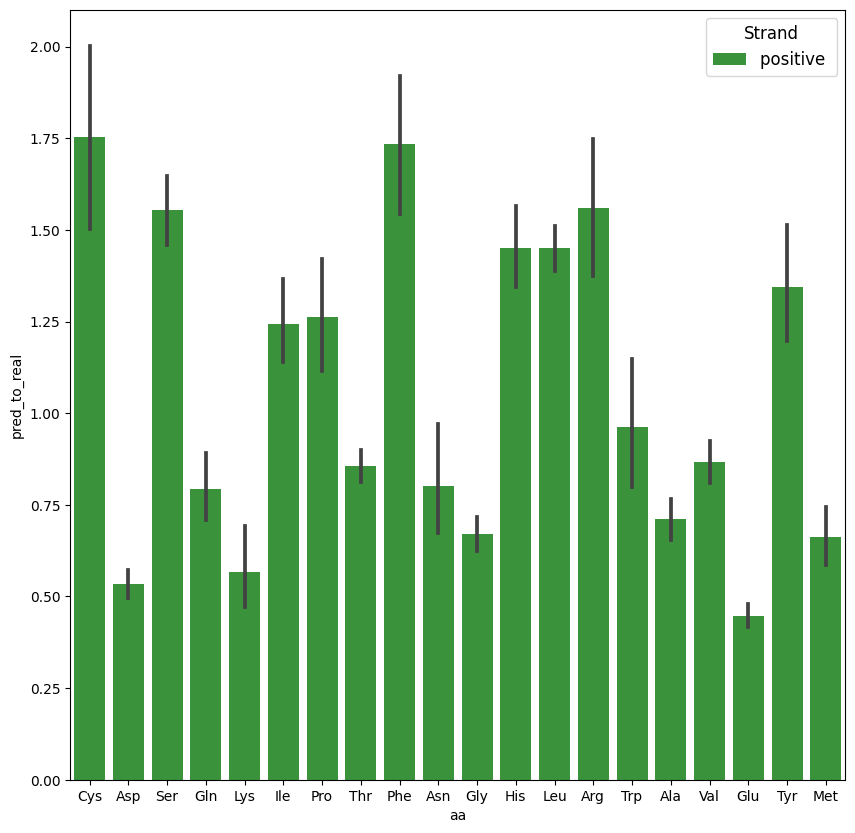

In [116]:
d = {'C': 'Cys', 'D': 'Asp', 'S': 'Ser', 'Q': 'Gln', 'K': 'Lys',
     'I': 'Ile', 'P': 'Pro', 'T': 'Thr', 'F': 'Phe', 'N': 'Asn', 
     'G': 'Gly', 'H': 'His', 'L': 'Leu', 'R': 'Arg', 'W': 'Trp', 
     'A': 'Ala', 'V':'Val', 'E': 'Glu', 'Y': 'Tyr', 'M': 'Met'}
palette = {
    'double': 'tab:orange',
    'positive ': 'tab:green',
    'negative' : 'tab:blue'
}
fig = plt.figure(figsize=(10, 10))
order_list = list(d.values())
ax = sns.barplot(x="aa", y='pred_to_real', hue="Strand", data=plus, ax=fig.gca(), palette=palette, order = order_list)
fig.savefig('../figures/ratio_aa_plus.pdf', dpi=300, bbox_inches = 'tight')

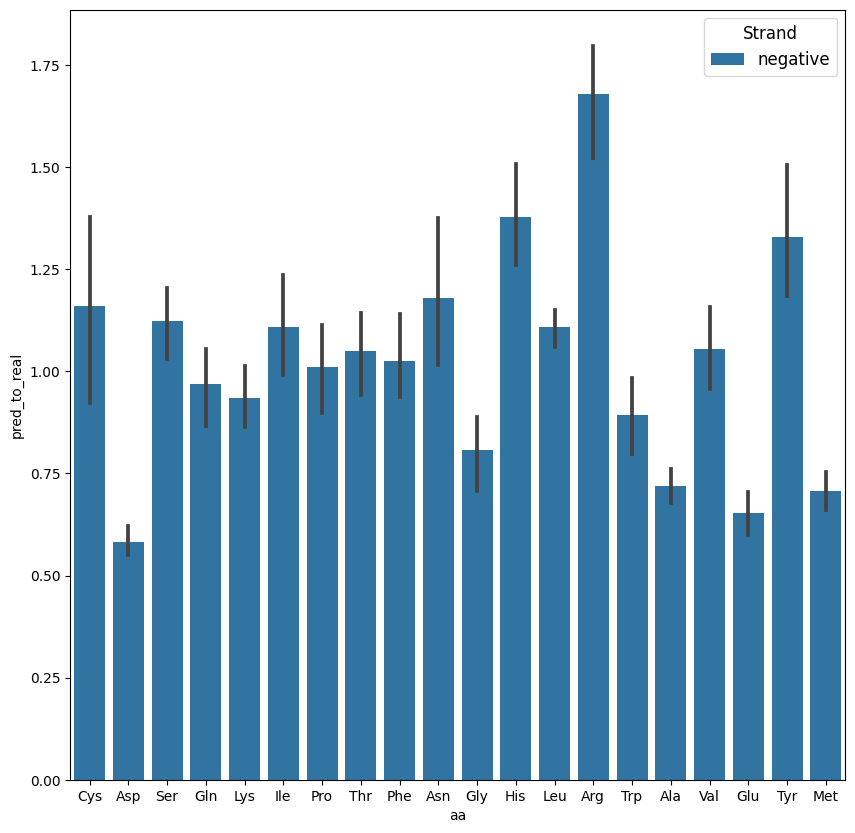

In [117]:
d = {'C': 'Cys', 'D': 'Asp', 'S': 'Ser', 'Q': 'Gln', 'K': 'Lys',
     'I': 'Ile', 'P': 'Pro', 'T': 'Thr', 'F': 'Phe', 'N': 'Asn', 
     'G': 'Gly', 'H': 'His', 'L': 'Leu', 'R': 'Arg', 'W': 'Trp', 
     'A': 'Ala', 'V':'Val', 'E': 'Glu', 'Y': 'Tyr', 'M': 'Met'}
palette = {
    'double': 'tab:orange',
    'positive ': 'tab:green',
    'negative' : 'tab:blue'
}
fig = plt.figure(figsize=(10, 10))
order_list = list(d.values())
ax = sns.barplot(x="aa", y='pred_to_real', hue="Strand", data=minus, ax=fig.gca(), palette=palette, order = order_list)
fig.savefig('../figures/ratio_aa_minus.pdf', dpi=300, bbox_inches = 'tight')

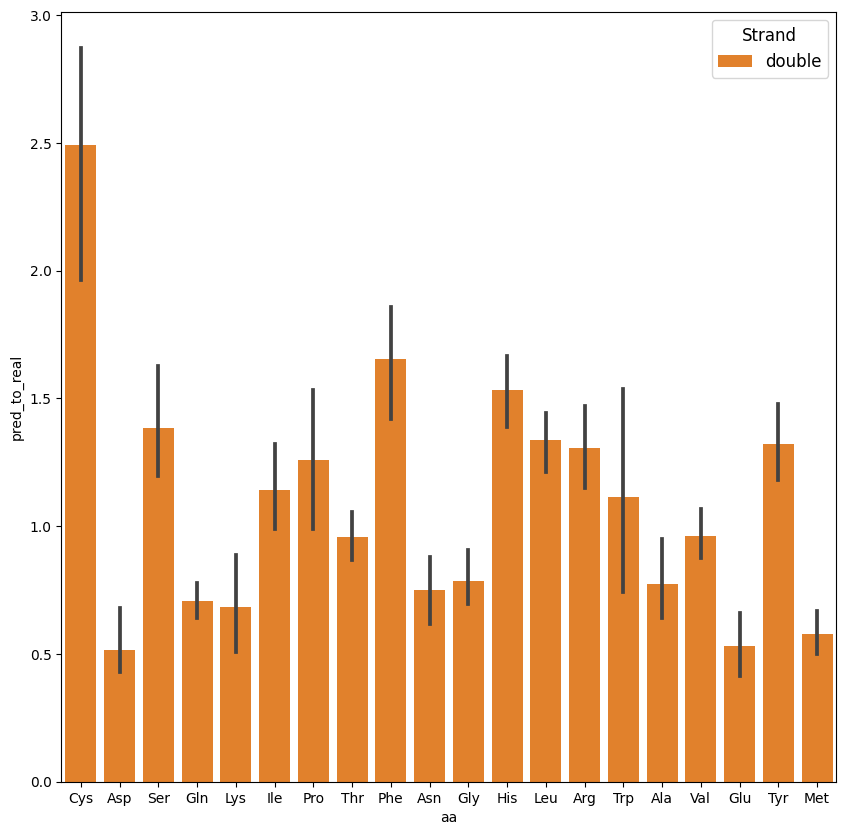

In [118]:
d = {'C': 'Cys', 'D': 'Asp', 'S': 'Ser', 'Q': 'Gln', 'K': 'Lys',
     'I': 'Ile', 'P': 'Pro', 'T': 'Thr', 'F': 'Phe', 'N': 'Asn', 
     'G': 'Gly', 'H': 'His', 'L': 'Leu', 'R': 'Arg', 'W': 'Trp', 
     'A': 'Ala', 'V':'Val', 'E': 'Glu', 'Y': 'Tyr', 'M': 'Met'}
palette = {
    'double': 'tab:orange',
    'positive ': 'tab:green',
    'negative' : 'tab:blue'
}
fig = plt.figure(figsize=(10, 10))
order_list = list(d.values())
ax = sns.barplot(x="aa", y='pred_to_real', hue="Strand", data=ds, ax=fig.gca(), palette=palette, order = order_list)
fig.savefig('../figures/ratio_aa_ds.pdf', dpi=300, bbox_inches = 'tight')

In [119]:
concat = pd.concat([plus, minus, ds])

In [120]:
concat = concat.reset_index(drop=True)

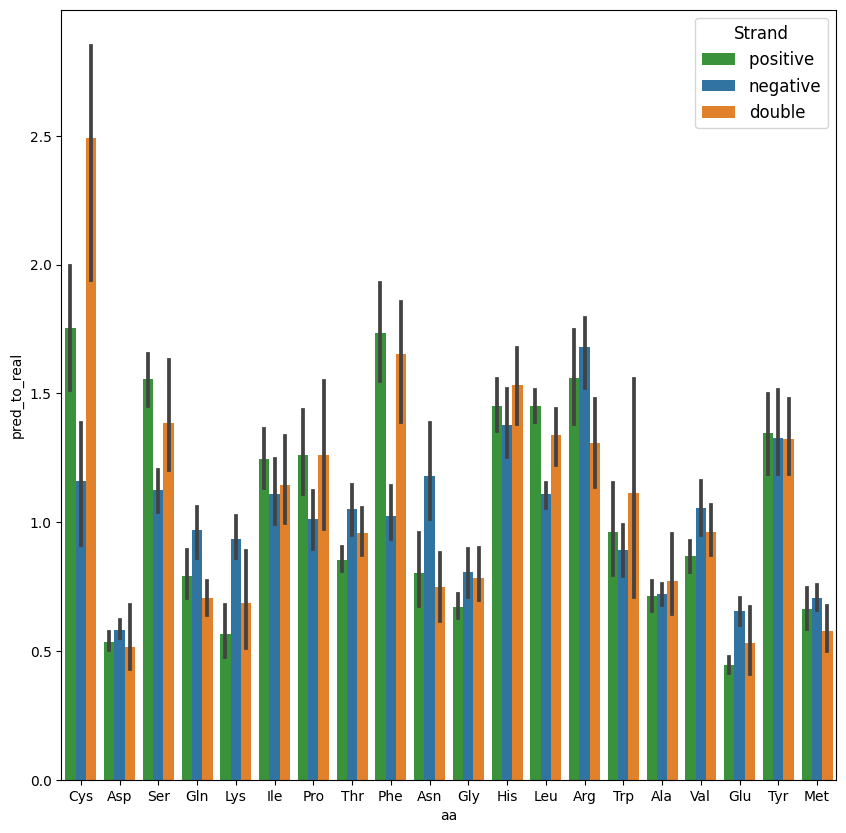

In [121]:
d = {'C': 'Cys', 'D': 'Asp', 'S': 'Ser', 'Q': 'Gln', 'K': 'Lys',
     'I': 'Ile', 'P': 'Pro', 'T': 'Thr', 'F': 'Phe', 'N': 'Asn', 
     'G': 'Gly', 'H': 'His', 'L': 'Leu', 'R': 'Arg', 'W': 'Trp', 
     'A': 'Ala', 'V':'Val', 'E': 'Glu', 'Y': 'Tyr', 'M': 'Met'}
palette = {
    'double': 'tab:orange',
    'positive ': 'tab:green',
    'negative' : 'tab:blue'
}
fig = plt.figure(figsize=(10, 10))
order_list = list(d.values())
ax = sns.barplot(x="aa", y='pred_to_real', hue="Strand", data=concat, ax=fig.gca(), palette=palette, order = order_list)
fig.savefig('../figures/ratio_aa_concat.pdf', dpi=300, bbox_inches = 'tight')

In [122]:
#minus = minus.rename(columns={"count": "count_minus", 'predict_count': "predict_count_minus"})
plus_merge = plus[['aa', 'count', 'Strand', 'predict_count', 'pred_to_real']]
plus_merge = pd.pivot_table(plus_merge, values=['count', 'pred_to_real'], index=['aa', 'Strand', 'predict_count'], aggfunc="mean").reset_index()
minus_merge = minus[['aa', 'count', 'Strand', 'predict_count', 'pred_to_real']]
minus_merge = pd.pivot_table(minus_merge, values=['count', 'pred_to_real'], index=['aa', 'Strand', 'predict_count'], aggfunc="mean").reset_index()
plus_minus = plus_merge.merge(minus_merge, how='inner', on='aa')

In [123]:
plus_minus['count_dif'] = plus_minus['count_x'] - plus_minus['count_y']
plus_minus['count_predict_dif'] = plus_minus['predict_count_x'] - plus_minus['predict_count_y']

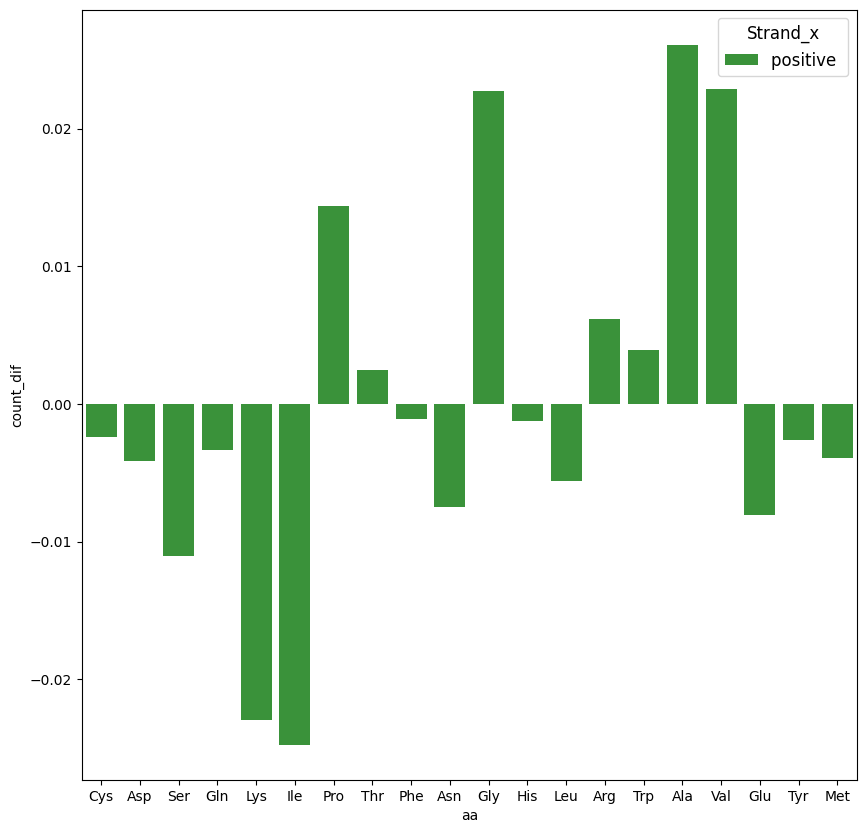

In [124]:
d = {'C': 'Cys', 'D': 'Asp', 'S': 'Ser', 'Q': 'Gln', 'K': 'Lys',
     'I': 'Ile', 'P': 'Pro', 'T': 'Thr', 'F': 'Phe', 'N': 'Asn', 
     'G': 'Gly', 'H': 'His', 'L': 'Leu', 'R': 'Arg', 'W': 'Trp', 
     'A': 'Ala', 'V':'Val', 'E': 'Glu', 'Y': 'Tyr', 'M': 'Met'}
palette = {
    'double': 'tab:orange',
    'positive ': 'tab:green',
    'negative' : 'tab:blue'
}
fig = plt.figure(figsize=(10, 10))
order_list = list(d.values())
ax = sns.barplot(x="aa", y='count_dif', hue="Strand_x", data=plus_minus, ax=fig.gca(), palette=palette, order = order_list)
fig.savefig('../figures/count_dif_real.pdf', dpi=300, bbox_inches = 'tight')

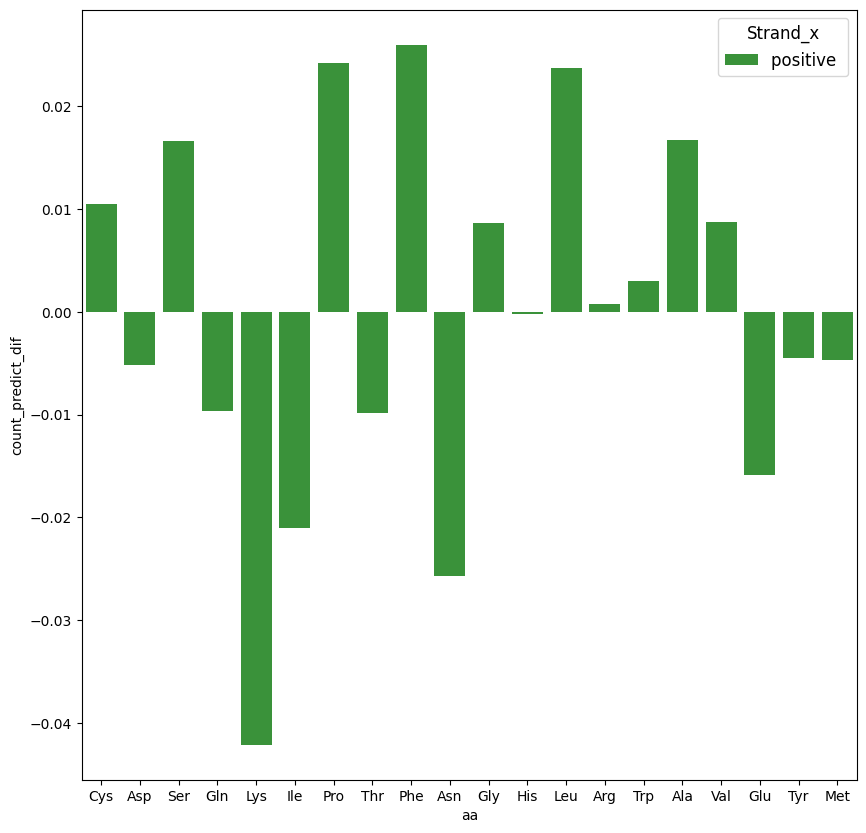

In [125]:
d = {'C': 'Cys', 'D': 'Asp', 'S': 'Ser', 'Q': 'Gln', 'K': 'Lys',
     'I': 'Ile', 'P': 'Pro', 'T': 'Thr', 'F': 'Phe', 'N': 'Asn', 
     'G': 'Gly', 'H': 'His', 'L': 'Leu', 'R': 'Arg', 'W': 'Trp', 
     'A': 'Ala', 'V':'Val', 'E': 'Glu', 'Y': 'Tyr', 'M': 'Met'}
palette = {
    'double': 'tab:orange',
    'positive ': 'tab:green',
    'negative' : 'tab:blue'
}
fig = plt.figure(figsize=(10, 10))
order_list = list(d.values())
ax = sns.barplot(x="aa", y='count_predict_dif', hue="Strand_x", data=plus_minus, ax=fig.gca(), palette=palette, order = order_list)
fig.savefig('../figures/count_dif_predict.pdf', dpi=300, bbox_inches = 'tight')

In [126]:
viruses_aa_freq_nooutlier = viruses_aa_freq[~viruses_aa_freq['virus_name'].isin(['694014', '693997'])] #'10990', '28295'

In [127]:
check_number = viruses_aa_freq[['virus_name', 'Strand']].drop_duplicates()
check_number['Strand'].value_counts()

positive     17
double        7
negative      7
              1
Name: Strand, dtype: int64

In [128]:
viruses_aa_freq_eq

,virus_name,Ala,Arg,Asn,Asp,Cys,Gln,Glu,Gly,His,...,Lys,Met,Phe,Pro,Ser,Thr,Trp,Tyr,Val,RNAsense
0,10407,0.059210,0.080345,0.033741,0.027613,0.031618,0.031575,0.021135,0.039762,0.041180,...,0.025728,0.013406,0.044461,0.088078,0.110885,0.072755,0.010922,0.038877,0.055946,ds
1,10990,0.022529,0.030072,0.029765,0.016467,0.038834,0.014140,0.007543,0.012196,0.030936,...,0.013792,0.011718,0.159932,0.041474,0.123110,0.045076,0.006091,0.069103,0.056643,ds
2,11082,0.055157,0.079762,0.033672,0.030789,0.038733,0.028378,0.024606,0.050760,0.032109,...,0.026766,0.017244,0.051881,0.054356,0.104354,0.060487,0.015782,0.042462,0.071759,+
3,11320,0.032330,0.091079,0.068530,0.036377,0.021084,0.039971,0.058749,0.045838,0.024603,...,0.112241,0.022854,0.022921,0.022421,0.073775,0.064574,0.011201,0.039634,0.055139,-
4,11983,0.054221,0.075625,0.035377,0.027691,0.033093,0.030276,0.021404,0.038329,0.039170,...,0.027288,0.014397,0.050699,0.076703,0.110759,0.069446,0.011231,0.042423,0.058721,+
5,12092,0.029037,0.047685,0.039339,0.026068,0.042966,0.019651,0.018649,0.029356,0.026510,...,0.027795,0.018460,0.106732,0.024914,0.102290,0.046161,0.012263,0.064799,0.073690,+
6,12110,0.081325,0.100855,0.020110,0.026538,0.035720,0.026546,0.019530,0.059465,0.035803,...,0.014980,0.011496,0.034913,0.110508,0.110169,0.062349,0.015170,0.026681,0.062386,+
7,12162,0.062533,0.084618,0.020647,0.028035,0.047233,0.020517,0.022085,0.065570,0.026030,...,0.016277,0.016180,0.060648,0.058506,0.107985,0.046547,0.020999,0.035746,0.084412,+
8,12637,0.049930,0.096440,0.057605,0.036272,0.021556,0.046021,0.046510,0.052505,0.034188,...,0.070893,0.018462,0.020033,0.046389,0.083875,0.080209,0.011476,0.035192,0.051494,+
9,28295,0.029724,0.036246,0.022908,0.015574,0.039650,0.013971,0.006522,0.014540,0.032639,...,0.009306,0.010069,0.152767,0.059247,0.132797,0.046611,0.006697,0.059433,0.056417,+


In [129]:
viruses_aa_freq_eq_nooutlier = viruses_aa_freq_eq[~viruses_aa_freq_eq['virus_name'].isin(['693997', '10990', '28295', '694014'])]

In [130]:
mean_plus_spec_pred = pd.DataFrame(viruses_aa_freq_eq_nooutlier[viruses_aa_freq_eq_nooutlier['RNAsense'] == '+'].drop(['virus_name', 'RNAsense'], axis=1).mean(axis=0)).reset_index().rename(columns={"index": "aa", 0:'predict_count'})
mean_plus_spec_pred['strand'] = 'positive '
mean_minus_spec_pred = pd.DataFrame(viruses_aa_freq_eq_nooutlier[viruses_aa_freq_eq_nooutlier['RNAsense'] == '-'].drop(['virus_name', 'RNAsense'], axis=1).mean(axis=0)).reset_index().rename(columns={"index": "aa", 0:'predict_count'})
mean_minus_spec_pred['strand'] = 'negative'
mean_ds_spec_pred = pd.DataFrame(viruses_aa_freq_eq_nooutlier[viruses_aa_freq_eq_nooutlier['RNAsense'] == 'ds'].drop(['virus_name', 'RNAsense'], axis=1).mean(axis=0)).reset_index().rename(columns={"index": "aa", 0:'predict_count'})
mean_ds_spec_pred['strand'] = 'double'
mean_plus_spec_real = viruses_aa_freq_nooutlier[viruses_aa_freq_nooutlier['Strand'] == 'positive ']
mean_minus_spec_real = viruses_aa_freq_nooutlier[viruses_aa_freq_nooutlier['Strand'] == 'negative']
mean_ds_spec_real = viruses_aa_freq_nooutlier[viruses_aa_freq_nooutlier['Strand'] == 'double']
plus = mean_plus_spec_real.merge(mean_plus_spec_pred, how='inner', on='aa')
minus = mean_minus_spec_real.merge(mean_minus_spec_pred, how='inner', on='aa')
ds = mean_ds_spec_real.merge(mean_ds_spec_pred, how='inner', on='aa')
plus['pred_to_real'] = plus['predict_count'] / plus['count']
minus['pred_to_real'] = minus['predict_count'] / minus['count']
ds['pred_to_real'] = ds['predict_count'] / ds['count']
plus_merge = plus[['aa', 'count', 'Strand', 'predict_count', 'pred_to_real']]
plus_merge = pd.pivot_table(plus_merge, values=['count', 'pred_to_real'], index=['aa', 'Strand', 'predict_count'], aggfunc="mean").reset_index()
minus_merge = minus[['aa', 'count', 'Strand', 'predict_count', 'pred_to_real']]
minus_merge = pd.pivot_table(minus_merge, values=['count', 'pred_to_real'], index=['aa', 'Strand', 'predict_count'], aggfunc="mean").reset_index()
plus_minus_no_out = plus_merge.merge(minus_merge, how='inner', on='aa')
plus_minus_no_out['count_dif'] = plus_minus_no_out['count_x'] - plus_minus_no_out['count_y']
plus_minus_no_out['count_predict_dif'] = plus_minus_no_out['predict_count_x'] - plus_minus_no_out['predict_count_y']

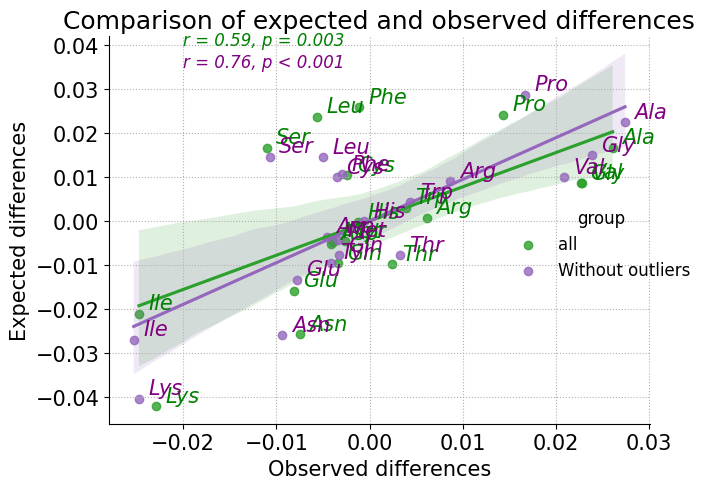

In [131]:
plus_minus['count_predict_dif'] = plus_minus['count_predict_dif'].astype(np.float64)
plus_minus['group'] = 'all'
plus_minus_no_out['count_predict_dif'] = plus_minus_no_out['count_predict_dif'].astype(np.float64)
plus_minus_no_out['group'] = 'Without outliers'

concat = pd.concat([plus_minus, plus_minus_no_out])
#g = sns.JointGrid(data=plus_minus, x='count_dif', y='count_predict_dif')
#g = g.plot_joint(sns.regplot, color="xkcd:muted blue")
#g = g.plot_marginals(sns.distplot, kde=False, bins=12, color="xkcd:bluey grey")
#plt.rcParams["figure.figsize"] = (20,20)
plt.rcParams['legend.fontsize'] = 'large'
plt.rcParams['legend.title_fontsize'] = 'large'
palette = {
    'all': 'tab:green',
    'Without outliers': 'tab:purple'
}
g = sns.lmplot(x = "count_dif", y = "count_predict_dif",
           hue = "group", data = concat, palette = palette)
#g.ax_joint.text(-0.02, 0.05, 'r = 0.45, p = 0.0023', fontstyle='italic')
plt.text(x=-0.02, y=0.04, s='r = 0.59, p = 0.003', fontsize=12, color='green' , fontstyle='italic')
plt.text(x=-0.02, y=0.035, s='r = 0.76, p < 0.001', fontsize=12, color='purple' , fontstyle='italic')
g.ax.grid(True, axis='both', ls=':')

for x, y, text, group in zip(concat['count_dif'], concat['count_predict_dif'], concat['aa'], concat['group'] ):
    if group == 'all':
        color = 'green'
    else:
        color = 'purple'
    plt.text(x=x+0.001, y=y+0.001, s=text, fontstyle='italic', fontsize=15, color=color)
    
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Observed differences',fontsize=15)
plt.ylabel('Expected differences',fontsize=15)
plt.title('Comparison of expected and observed differences',fontsize=18)
plt.tight_layout()
plt.savefig('../figures/supp_14_corr_real_predict.pdf', dpi=300, bbox_inches = 'tight')

In [132]:
#pg.corr(x=plus_minus['count_dif'], y=plus_minus['count_predict_dif'])
from scipy import stats
print(stats.pearsonr(plus_minus['count_dif'], plus_minus['count_predict_dif'], alternative='greater'))
print(stats.pearsonr(plus_minus_no_out['count_dif'], plus_minus_no_out['count_predict_dif'], alternative='greater'))

PearsonRResult(statistic=0.5892204427153085, pvalue=0.003130603358362173)
PearsonRResult(statistic=0.7596628636549217, pvalue=5.106247069126112e-05)


In [133]:
concat

,aa,Strand_x,predict_count_x,count_x,pred_to_real_x,Strand_y,predict_count_y,count_y,pred_to_real_y,count_dif,count_predict_dif,group
0,Ala,positive,0.052739,0.076518,0.711636,negative,0.036076,0.050419,0.719787,0.026099,0.016663,all
1,Arg,positive,0.074829,0.050959,1.559615,negative,0.074030,0.044763,1.678966,0.006196,0.000799,all
2,Asn,positive,0.031141,0.042677,0.802026,negative,0.056852,0.050171,1.179264,-0.007494,-0.025711,all
3,Asp,positive,0.026709,0.050931,0.534663,negative,0.031871,0.055078,0.582452,-0.004147,-0.005162,all
4,Cys,positive,0.038024,0.023627,1.752243,negative,0.027557,0.026006,1.158871,-0.002380,0.010467,all
5,Gln,positive,0.024574,0.032731,0.792724,negative,0.034195,0.036102,0.967817,-0.003372,-0.009621,all
6,Glu,positive,0.022090,0.050650,0.446517,negative,0.037954,0.058745,0.654078,-0.008095,-0.015864,all
7,Gly,positive,0.046819,0.071412,0.669590,negative,0.038219,0.048698,0.807306,0.022714,0.008600,all
8,His,positive,0.030987,0.021806,1.451506,negative,0.031243,0.023055,1.377196,-0.001249,-0.000256,all
9,Ile,positive,0.062314,0.052126,1.244362,negative,0.083361,0.076879,1.109197,-0.024754,-0.021046,all


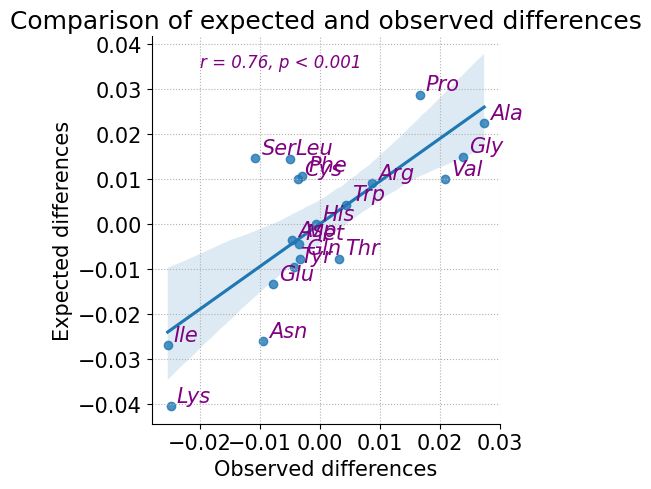

In [135]:
#plus_minus['count_predict_dif'] = plus_minus['count_predict_dif'].astype(np.float64)
#plus_minus['group'] = 'all'
#plus_minus_no_out['count_predict_dif'] = plus_minus_no_out['count_predict_dif'].astype(np.float64)
#plus_minus_no_out['group'] = 'without outliers'

#concat = pd.concat([plus_minus, plus_minus_no_out])
#g = sns.JointGrid(data=plus_minus, x='count_dif', y='count_predict_dif')
#g = g.plot_joint(sns.regplot, color="xkcd:muted blue")
#g = g.plot_marginals(sns.distplot, kde=False, bins=12, color="xkcd:bluey grey")
plt.rcParams["figure.figsize"] = (15,15)
plt.rcParams['legend.fontsize'] = 'large'
plt.rcParams['legend.title_fontsize'] = 'large'
palette = {
    'all': 'tab:green',
    'without outliers': 'tab:purple'
}
g = sns.lmplot(x = "count_dif", y = "count_predict_dif", data = concat[concat['group'] == 'Without outliers'])
#g.ax_joint.text(-0.02, 0.05, 'r = 0.45, p = 0.0023', fontstyle='italic')
#plt.text(x=-0.02, y=0.04, s='r = 0.63, p = 0.005', fontsize=12, color='green' , fontstyle='italic')
g.ax.grid(True, axis='both', ls=':')
plt.text(x=-0.02, y=0.035, s='r = 0.76, p < 0.001', fontsize=12, color='purple' , fontstyle='italic')

for x, y, text, group in zip(concat['count_dif'], concat['count_predict_dif'], concat['aa'], concat['group'] ):
    if group == 'Without outliers':
        color = 'purple'
        plt.text(x=x+0.001, y=y+0.001, s=text, fontstyle='italic', fontsize=15, color=color)
    
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Observed differences',fontsize=15)
plt.ylabel('Expected differences',fontsize=15)
plt.title('Comparison of expected and observed differences',fontsize=18)
plt.tight_layout()
plt.savefig('../figures/corr_real_predict_only_all.pdf', dpi=300, bbox_inches = 'tight')

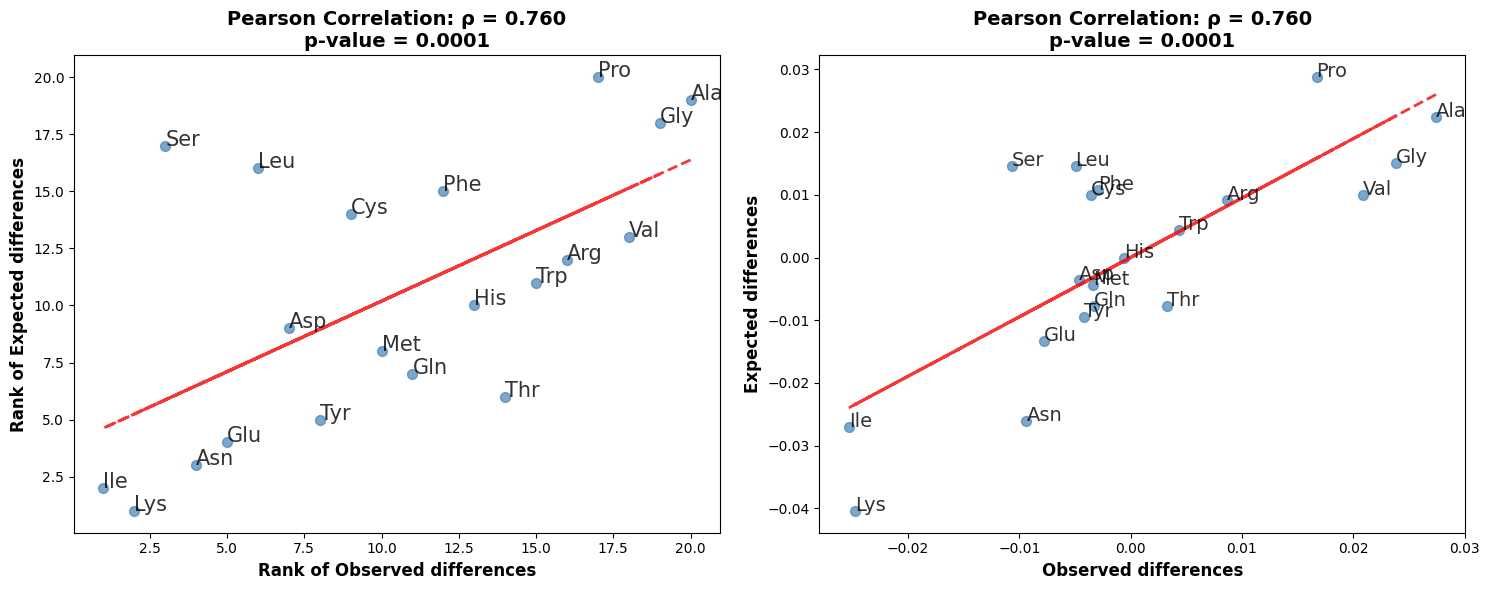

In [138]:
data_fig = concat[concat['group'] == 'Without outliers']
x = data_fig['count_dif']
y = data_fig["count_predict_dif"]
aa_list = list(data_fig['aa'])

# Вычисляем корреляцию
corr, p_value = stats.pearsonr(x, y)

# Считаем ранги
x_ranks = stats.rankdata(x)
y_ranks = stats.rankdata(y)

# Создаем график
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Scatter plot рангов
scatter = ax1.scatter(x_ranks, y_ranks, alpha=0.7, color='steelblue', s=50)
ax1.set_xlabel('Rank of Observed differences', fontsize=12, fontweight='bold')
ax1.set_ylabel('Rank of Expected differences', fontsize=12, fontweight='bold')
ax1.set_title(f'Pearson Correlation: ρ = {corr:.3f}\np-value = {p_value:.4f}', 
              fontsize=14, fontweight='bold')

for i, txt in enumerate(aa_list):
    ax1.annotate(txt, (x_ranks[i], y_ranks[i]), 
                 fontsize=15, alpha=0.8)

# Добавляем линию тренда для рангов
z_rank = np.polyfit(x_ranks, y_ranks, 1)
p_rank = np.poly1d(z_rank)
ax1.plot(x_ranks, p_rank(x_ranks), "r--", alpha=0.8, linewidth=2)

# 2. Scatter plot исходных данных
scatter2 = ax2.scatter(x, y, alpha=0.7, color='steelblue', s=50)
ax2.set_xlabel('Observed differences', fontsize=12, fontweight='bold')
ax2.set_ylabel('Expected differences', fontsize=12, fontweight='bold')
ax2.set_title(f'Pearson Correlation: ρ = {corr:.3f}\np-value = {p_value:.4f}', 
              fontsize=14, fontweight='bold')

for i, txt in enumerate(aa_list):
    ax2.annotate(txt, (x[i], y[i]), 
                 fontsize=14, alpha=0.8)

# Добавляем линию тренда для исходных данных
z_orig = np.polyfit(x, y, 1)
p_orig = np.poly1d(z_orig)
ax2.plot(x, p_orig(x), "r--", alpha=0.8, linewidth=2)

# Добавляем цветовую шкалу
#cbar = plt.colorbar(scatter, ax=ax1)
#cbar.set_label('Absolute PC1 Weight', fontsize=10)
#cbar2 = plt.colorbar(scatter2, ax=ax2)
#cbar2.set_label('Absolute PC1 Weight', fontsize=10)

plt.tight_layout()
plt.savefig('../figures/fig_3d_corr_real_predict.pdf', dpi=300, bbox_inches = 'tight')
plt.show()
plt.close()

In [49]:
concat = concat.rename(columns={'predict_count_x':'predict_positive', 'predict_count_y':'predict_negative'})
concat_to_save = concat[concat['group'] == 'without outliers'][['aa', 'count_predict_dif', 'predict_positive', 'predict_negative']]

In [50]:
concat_to_save.to_csv('../data_obtain/plus_minus_predict.csv')

In [89]:
#pg.corr(x=plus_minus['count_dif'], y=plus_minus['count_predict_dif'])
from scipy import stats
print(stats.pearsonr(plus_minus['count_dif'], plus_minus['count_predict_dif'], alternative='greater'))
print(stats.pearsonr(plus_minus_no_out['count_dif'], plus_minus_no_out['count_predict_dif'], alternative='greater'))

PearsonRResult(statistic=0.5892204427153085, pvalue=0.003130603358362173)
PearsonRResult(statistic=0.7596628636549217, pvalue=5.106247069126112e-05)


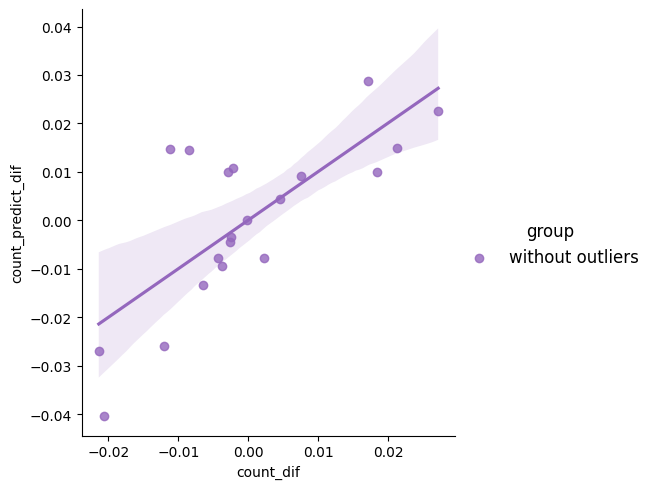

In [32]:
sns.lmplot(x = "count_dif", y = "count_predict_dif",
           hue = "group", data = plus_minus_no_out, palette = palette)

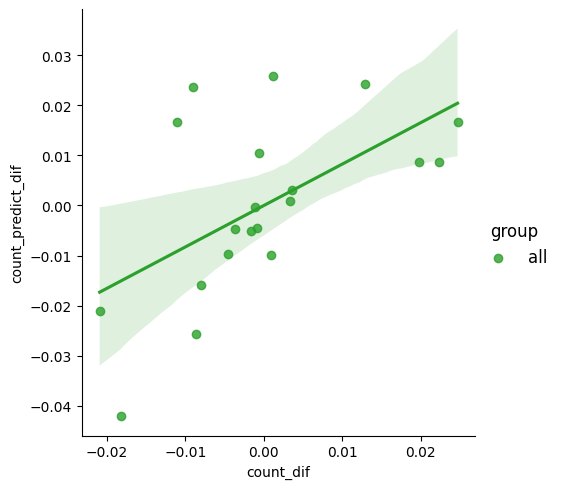

In [33]:
sns.lmplot(x = "count_dif", y = "count_predict_dif",
           hue = "group", data = plus_minus, palette = palette)

In [34]:
plus_minus_no_out

,aa,Strand_x,predict_count_x,count_x,pred_to_real_x,Strand_y,predict_count_y,count_y,pred_to_real_y,count_dif,count_predict_dif,group
0,Ala,positive,0.058535,0.079399,0.757908,negative,0.036076,0.052226,0.701105,0.027173,0.022458,without outliers
1,Arg,positive,0.083132,0.055267,1.548935,negative,0.074030,0.047653,1.598444,0.007614,0.009102,without outliers
2,Asn,positive,0.030838,0.040172,0.840498,negative,0.056852,0.052161,1.129692,-0.011989,-0.026015,without outliers
3,Asp,positive,0.028323,0.050370,0.572236,negative,0.031871,0.052892,0.608506,-0.002522,-0.003548,without outliers
4,Cys,positive,0.037574,0.020910,1.909493,negative,0.027557,0.023809,1.249078,-0.002899,0.010017,without outliers
5,Gln,positive,0.026493,0.032771,0.865473,negative,0.034195,0.037105,0.944909,-0.004334,-0.007701,without outliers
6,Glu,positive,0.024598,0.052849,0.474146,negative,0.037954,0.059350,0.648439,-0.006502,-0.013356,without outliers
7,Gly,positive,0.053234,0.072593,0.750113,negative,0.038219,0.051351,0.767087,0.021242,0.015015,without outliers
8,His,positive,0.031228,0.022715,1.397228,negative,0.031243,0.022849,1.408037,-0.000134,-0.000016,without outliers
9,Ile,positive,0.056407,0.051593,1.145798,negative,0.083361,0.072958,1.174378,-0.021364,-0.026954,without outliers


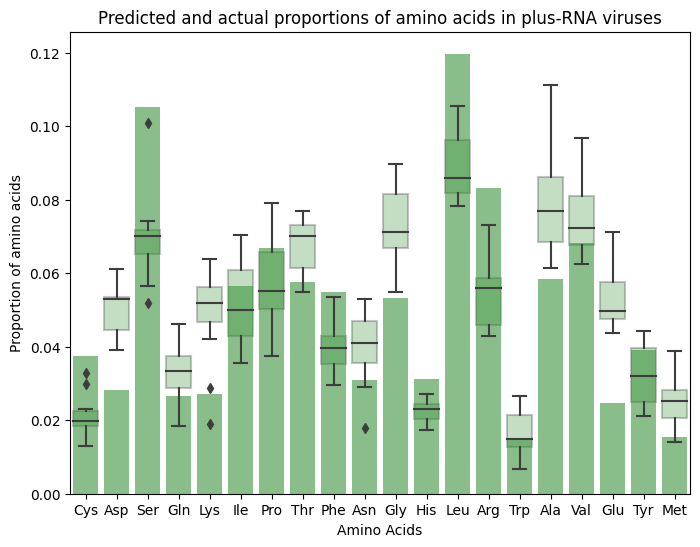

In [35]:
palette = {
    'double': 'tab:orange',
    'positive ': 'tab:green',
    'negative' : 'tab:blue'
}
plt.figure(figsize=(8,6))
sns.boxplot(x="aa",
                y="count",
                data=plus, hue="Strand", palette=palette, order = order_list, boxprops=dict(alpha=.3))
sns.barplot(x="aa", y='predict_count', data=plus, hue="Strand", palette=palette, order = order_list, alpha=0.6)
plt.xlabel("Amino Acids")
plt.ylabel("Proportion of amino acids")
plt.title('Predicted and actual proportions of amino acids in plus-RNA viruses')
plt.legend('',frameon=False)
plt.savefig('../figures/real_predict_positive.pdf', dpi=300, bbox_inches = 'tight')
plt.show()
plt.close()

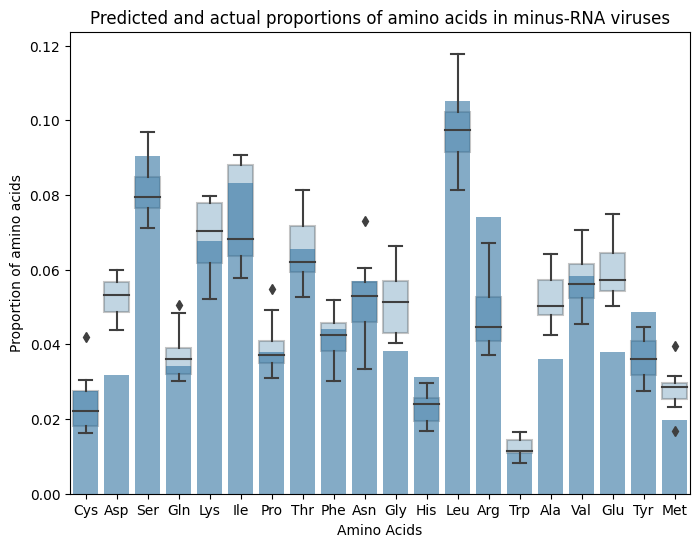

In [36]:
plt.figure(figsize=(8,6))
sns.boxplot(x="aa",
                y="count",
                data=minus, hue="Strand", palette=palette, order = order_list, boxprops=dict(alpha=.3))
sns.barplot(x="aa", y='predict_count', data=minus, hue="Strand", palette=palette, order = order_list, alpha=0.6)
plt.xlabel("Amino Acids")
plt.ylabel("Proportion of amino acids")
plt.title('Predicted and actual proportions of amino acids in minus-RNA viruses')
plt.legend('',frameon=False)
plt.savefig('../figures/real_predict_negative.pdf', dpi=300, bbox_inches = 'tight')
plt.show()
plt.close()

In [37]:
concat = pd.concat([plus, minus])

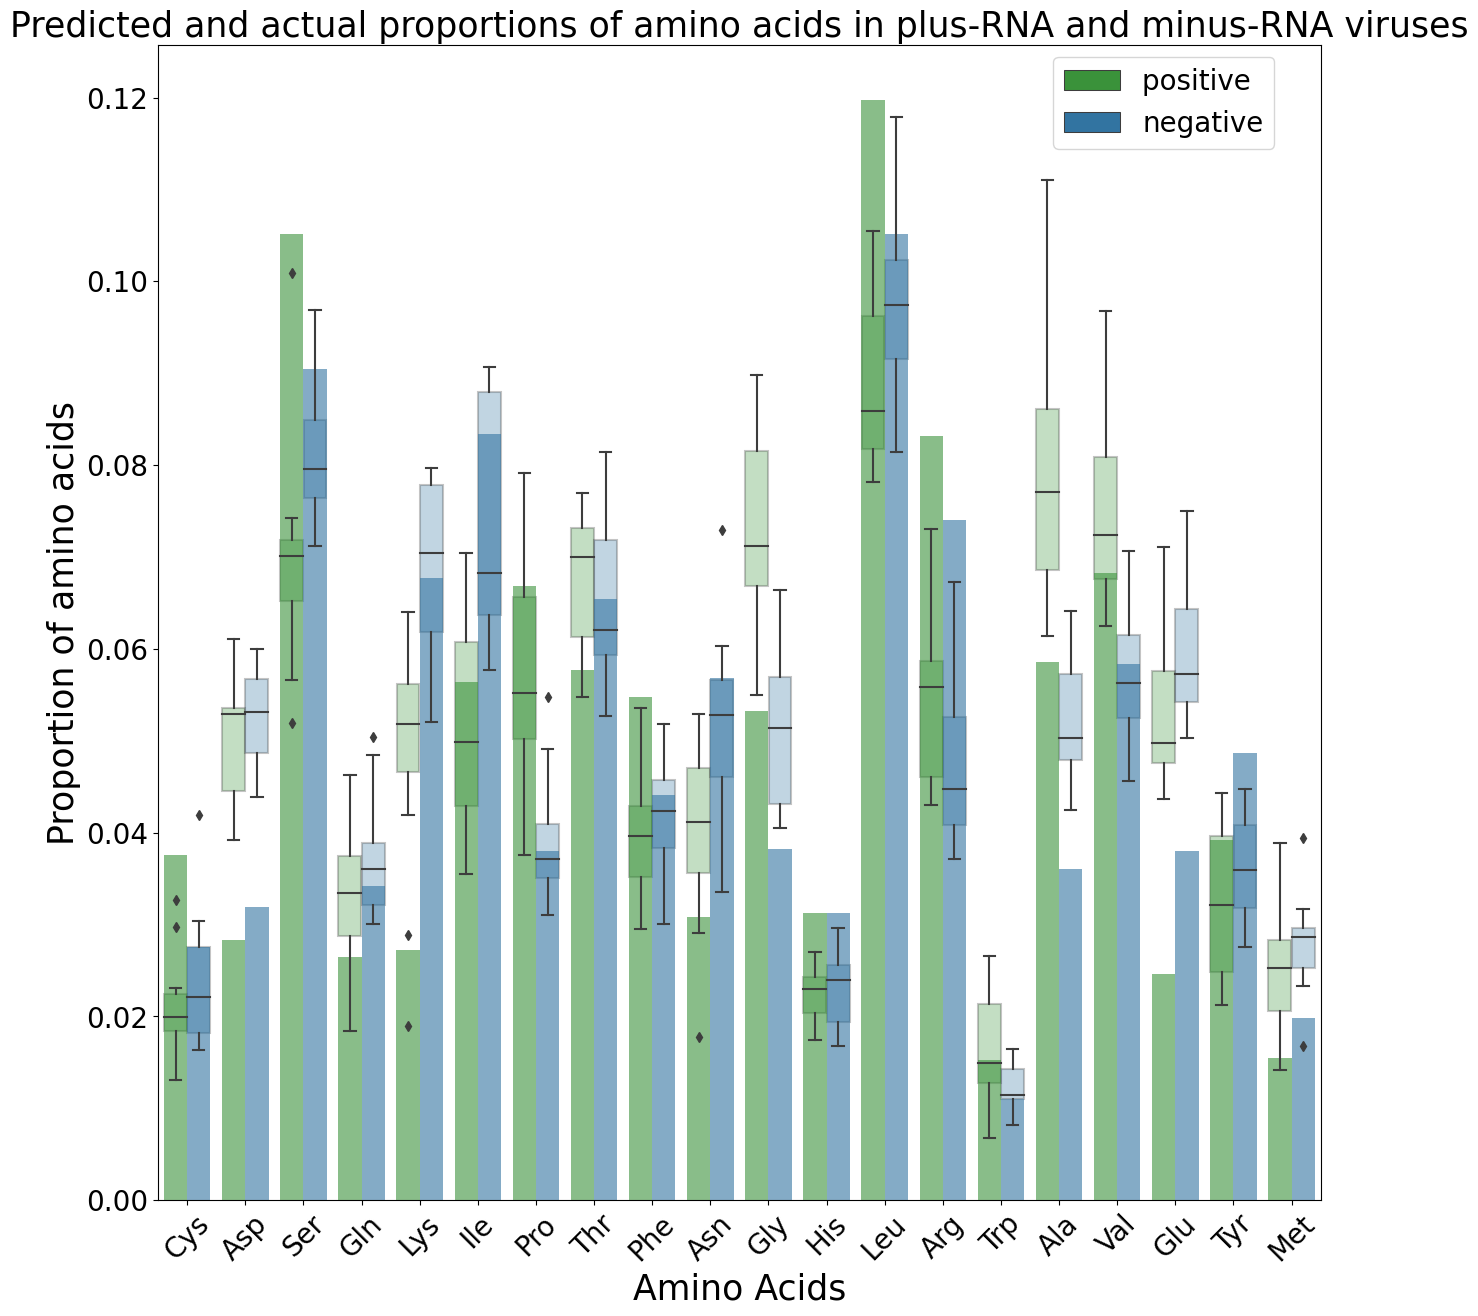

In [38]:
plt.figure(figsize=(15,15))
sns.boxplot(x="aa",
                y="count",
                data=concat, hue="Strand", palette=palette, order = order_list, boxprops=dict(alpha=.3))

ax = sns.barplot(x="aa", y='predict_count', data=concat, hue="Strand", palette=palette, order = order_list, alpha=0.6)
handles, labels = ax.get_legend_handles_labels()

# When creating the legend, only use the first two elements
# to effectively remove the last two.
l = plt.legend(handles[0:2], labels[0:2], bbox_to_anchor=(0.77, 0.99), loc=2, borderaxespad=0.,fontsize=20)
plt.xlabel("Amino Acids",fontsize=25)
plt.ylabel("Proportion of amino acids",fontsize=25)
plt.xticks(fontsize=20, rotation=45)
plt.yticks(fontsize=20)
plt.title('Predicted and actual proportions of amino acids in plus-RNA and minus-RNA viruses',fontsize=25)
#plt.legend('',frameon=False)
plt.savefig('../figures/real_predict_pos_neg.pdf', dpi=300, bbox_inches = 'tight')
plt.show()
plt.close()